<a href="https://colab.research.google.com/github/25sheraz/Heart-Disease-Prediction/blob/main/Task_no_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files

# This will open a file chooser dialog
uploaded = files.upload()

Saving heart_disease_uci.csv to heart_disease_uci.csv


/tmp/ipykernel_2671/3686937782.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


Summary Statistics:
               age    trestbps        chol      thalch     oldpeak          ca  \
count  920.000000  920.000000  920.000000  920.000000  920.000000  920.000000   
mean    53.510870  131.995652  199.908696  137.692391    0.853261    0.227174   
std      9.424685   18.451300  109.040171   25.145235    1.058049    0.628936   
min     28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000   
25%     47.000000  120.000000  177.750000  120.000000    0.000000    0.000000   
50%     54.000000  130.000000  223.000000  140.000000    0.500000    0.000000   
75%     60.000000  140.000000  267.000000  156.000000    1.500000    0.000000   
max     77.000000  200.000000  603.000000  202.000000    6.200000    3.000000   

       has_disease  
count   920.000000  
mean      0.553261  
std       0.497426  
min       0.000000  
25%       0.000000  
50%       1.000000  
75%       1.000000  
max       1.000000  

Target Distribution:
 has_disease
1    509
0    411
Name: c

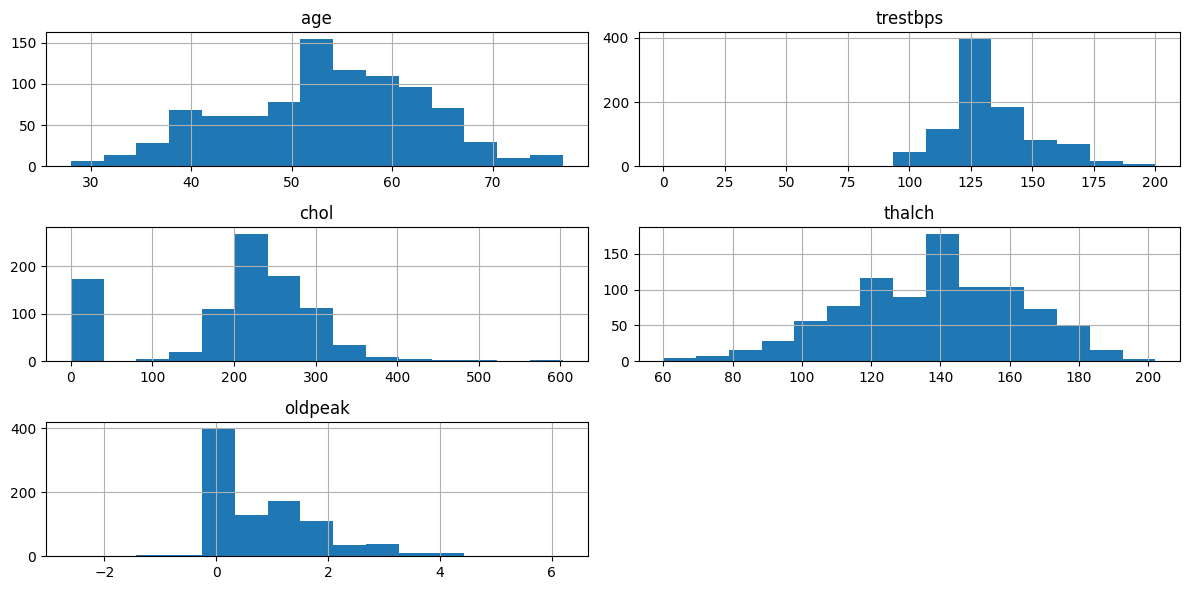

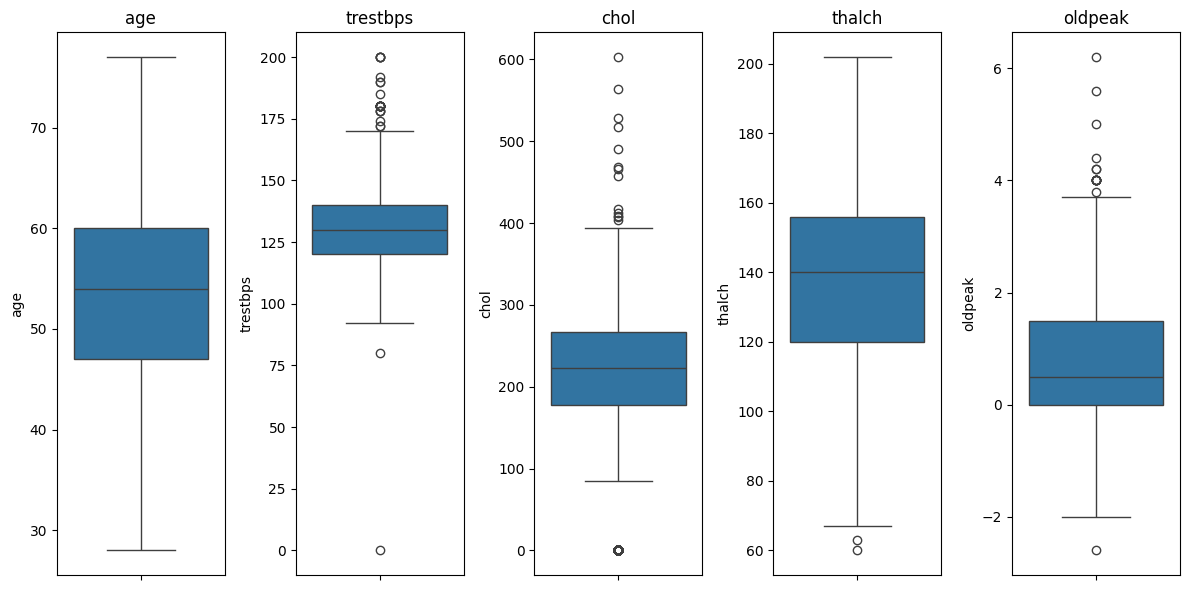

Accuracy Score: 0.8207

Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.83      0.79        75
           1       0.87      0.82      0.84       109

    accuracy                           0.82       184
   macro avg       0.81      0.82      0.82       184
weighted avg       0.83      0.82      0.82       184



/tmp/ipykernel_2671/3686937782.py:90: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette='magma')


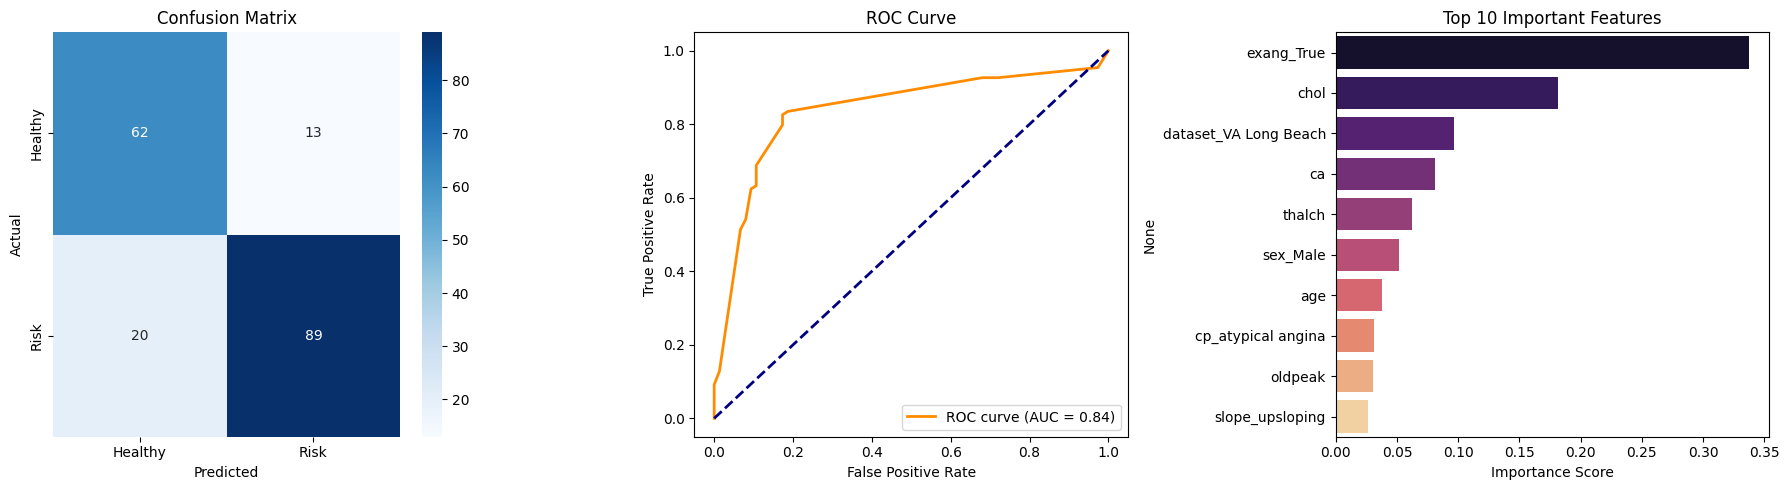

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_splita
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report

# 1. Load the dataset
df = pd.read_csv('heart_disease_uci.csv')

# 2. Data Cleaning
df = df.drop(columns=['id'])  # Drop 'id' as it's not a predictor

num_cols = ['trestbps', 'chol', 'thalch', 'oldpeak', 'ca']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = ['fbs', 'restecg', 'exang', 'slope', 'thal']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['has_disease'] = (df['num'] > 0).astype(int)
df = df.drop(columns=['num'])

# --- EDA: Added part ---
print("Summary Statistics:\n", df.describe())
print("\nTarget Distribution:\n", df['has_disease'].value_counts())

# Histograms for key numeric features
numeric_features = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
df[numeric_features].hist(figsize=(12,6), bins=15)
plt.tight_layout()
plt.show()

# Boxplots for key numeric features
plt.figure(figsize=(12,6))
for i, col in enumerate(numeric_features):
    plt.subplot(1, len(numeric_features), i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

# 3. Feature Engineering (One-Hot Encoding for categorical data)
data_encoded = pd.get_dummies(df, columns=['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], drop_first=True)

X = data_encoded.drop(columns=['has_disease'])
y = data_encoded['has_disease']

# 4. Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Train Decision Tree Classifier
clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

# 6. Predictions & Evaluation
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- Plotting Results ---
plt.figure(figsize=(18, 5))

# Confusion Matrix
plt.subplot(1, 3, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Risk'], yticklabels=['Healthy', 'Risk'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# ROC Curve
plt.subplot(1, 3, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")

# Feature Importance
plt.subplot(1, 3, 3)
importances = pd.Series(clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
sns.barplot(x=importances.values, y=importances.index, palette='magma')
plt.title('Top 10 Important Features')
plt.xlabel('Importance Score')

plt.tight_layout()
plt.savefig('heart_disease_results.png')
plt.show()
# Save cleaned data
df.to_csv('heart_disease_cleaned.csv', index=False)